**Problem Statement**

>Develop a machine learning model to classify different brain tumor types from high-dimensional gene expression data using Support Vector Machines (SVM). The project will investigate how dimensionality reduction and feature selection improve classification performance on genomic datasets with tens of thousands of gene expression features.

**Project Structure**

>1. Import Libraries
>2. Load Dataset
>3. Exploratory Data Analysis
4. Data Preprocessing
5. Feature Engineering
6. Model Building
7. Hyperparameter Tuning
8. Model Evaluation
9. Performance Comparison
10. Results & Discussion
11. Conclusion

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

dataset_path = "/content/drive/MyDrive/Datasets/Kaggle_Dataset_Bioinformatics/Bioinformatics/Brain_GSE50161.csv"

df = pd.read_csv(dataset_path)



In [ ]:
#Section 1: Importing Libraries

# ============================================
# Brain Cancer Classification using SVM
# ============================================

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score
)

from sklearn.preprocessing import (
    StandardScaler,
    LabelEncoder
)

from sklearn.feature_selection import (
    VarianceThreshold
)

from sklearn.decomposition import PCA

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.rcParams['figure.figsize'] = (8,6)
plt.rcParams['font.size'] = 12

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
#Section 2: Dataset Overview

print("="*60)
print("Brain Cancer Gene Expression Dataset")
print("="*60)

print(f"Dataset Shape : {df.shape}")

print(f"\nNumber of Samples : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("="*60)

Brain Cancer Gene Expression Dataset
Dataset Shape : (130, 54677)

Number of Samples : 130
Number of Columns : 54677


In [ ]:
#Section 3.1: Dataset Preview

df.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,834,ependymoma,12.498150,7.604868,6.880934,9.027128,4.176175,7.224920,6.085942,6.835999,...,9.979005,9.926470,12.719785,12.777792,5.403657,4.870548,4.047380,3.721936,4.516434,4.749940
1,835,ependymoma,13.067436,7.998090,7.209076,9.723322,4.826126,7.539381,6.250962,8.012549,...,11.924749,11.215930,13.605662,13.401342,5.224555,4.895315,3.786437,3.564481,4.430891,4.491416
2,836,ependymoma,13.068179,8.573674,8.647684,9.613002,4.396581,7.813101,6.007746,7.178156,...,12.154405,11.532460,13.764593,13.477800,5.303565,5.052184,4.005343,3.595382,4.563494,4.668827
3,837,ependymoma,12.456040,9.098977,6.628784,8.517677,4.154847,8.361843,6.596064,6.347285,...,11.969072,11.288801,13.600828,13.379029,4.953429,4.708371,3.892318,3.759429,4.748381,4.521275
4,838,ependymoma,12.699958,8.800721,11.556188,9.166309,4.165891,7.923826,6.212754,6.866387,...,11.411701,11.169317,13.751442,13.803646,4.892677,4.773806,3.796856,3.577544,4.504385,4.541450


In [ ]:
#Section 3.2: Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Columns: 54677 entries, samples to AFFX-TrpnX-M_at
dtypes: float64(54675), int64(1), object(1)
memory usage: 54.2+ MB


In [ ]:
#Section 3.3: Missing Values & Duplicate Samples

print("="*60)
print("Missing Values")
print("="*60)

print(df.isnull().sum().sum())

print("\nDuplicate Samples")

print(df.duplicated().sum())

Missing Values
0

Duplicate Samples
0


In [ ]:
#Section 3.4: Target Class Distribution

print(df["type"].value_counts())

type
ependymoma               46
glioblastoma             34
medulloblastoma          22
pilocytic_astrocytoma    15
normal                   13
Name: count, dtype: int64


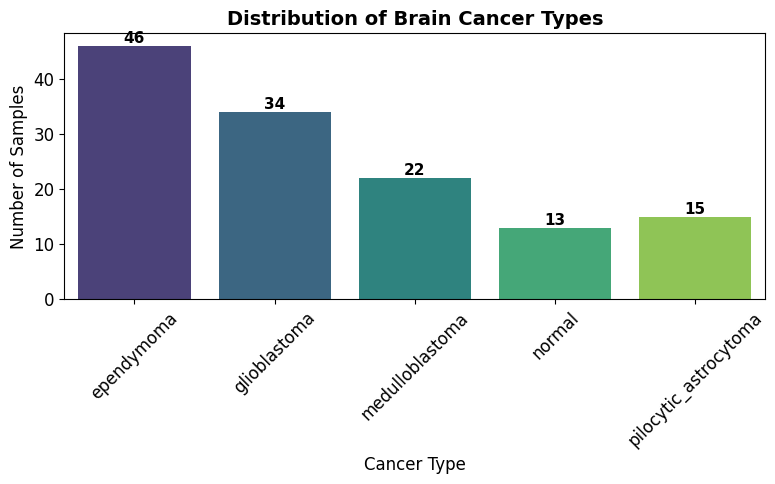

In [ ]:
#Section 3.5: Class Distribution Visualization

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="type",
    palette="viridis"
)

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=11, fontweight='bold')

plt.title("Distribution of Brain Cancer Types", fontsize=14, fontweight='bold')
plt.xlabel("Cancer Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
#Section 3.6: Dataset Summary Table

summary = pd.DataFrame({
    "Metric":[
        "Samples",
        "Gene Features",
        "Cancer Classes",
        "Missing Values",
        "Duplicate Samples"
    ],
    "Value":[
        df.shape[0],
        df.shape[1]-2,
        df["type"].nunique(),
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ]
})

summary

,Metric,Value
0,Samples,130
1,Gene Features,54675
2,Cancer Classes,5
3,Missing Values,0
4,Duplicate Samples,0


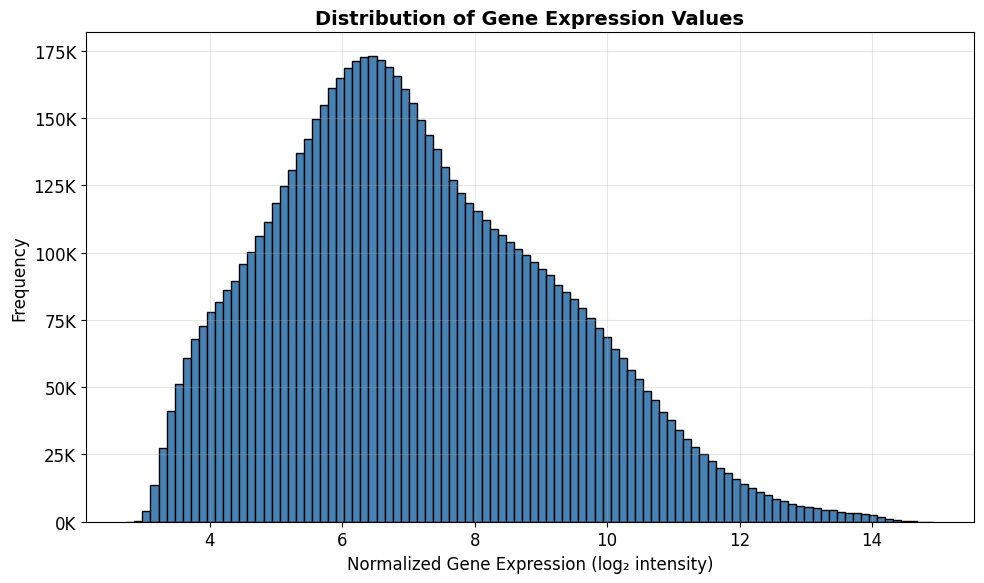

In [ ]:
#Section 3.7: Distribution of Gene Expression Values

from matplotlib.ticker import FuncFormatter

# Removing non-gene columns
gene_data = df.drop(columns=["samples", "type"])

# Flattening all gene expression values
expression_values = gene_data.values.flatten()

plt.figure(figsize=(10,6))

plt.hist(
    expression_values,
    bins=100,
    color="steelblue",
    edgecolor="black"
)

plt.title("Distribution of Gene Expression Values",
          fontsize=14,
          fontweight="bold")

# Format y-axis in thousands
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
)

plt.xlabel("Normalized Gene Expression (log₂ intensity)",fontsize=12)
plt.ylabel("Frequency",fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

>The distribution of normalized gene expression values provides an overview of the expression landscape across all genes and patient samples.

>The majority of expression values are concentrated within a relatively narrow range, indicating that most genes exhibit moderate expression levels after normalization.

>The absence of extreme outliers suggests that the dataset has been appropriately preprocessed, making it suitable for downstream machine learning analyses such as feature selection, dimensionality reduction, and SVM classification

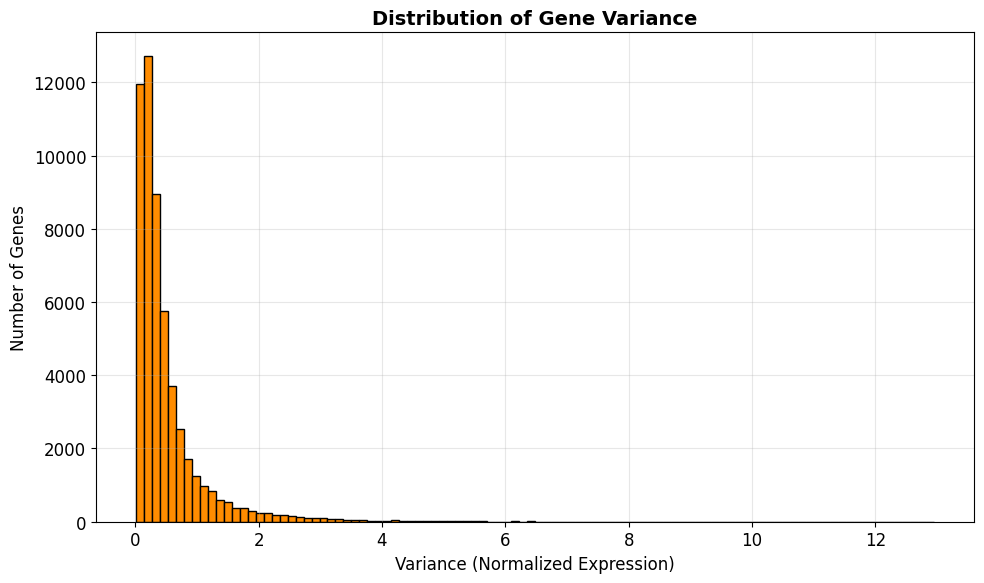

In [ ]:
#Section 3.8: Gene Variance Distribution

gene_variance = gene_data.var(axis=0)

plt.figure(figsize=(10,6))

plt.hist(
    gene_variance,
    bins=100,
    color="darkorange",
    edgecolor="black"
)

plt.title("Distribution of Gene Variance",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Variance (Normalized Expression)",fontsize=12)

plt.ylabel("Number of Genes",fontsize=12)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

>The variance distribution reveals that a large proportion of genes exhibit relatively low expression variability across patients, while a smaller subset of genes shows substantially higher variance.

>Genes with low variance contribute limited discriminatory information for classification, whereas highly variable genes are more likely to capture biologically meaningful differences between tumor types.

>This observation supports the application of variance-based feature selection to reduce dimensionality and improve model efficiency.

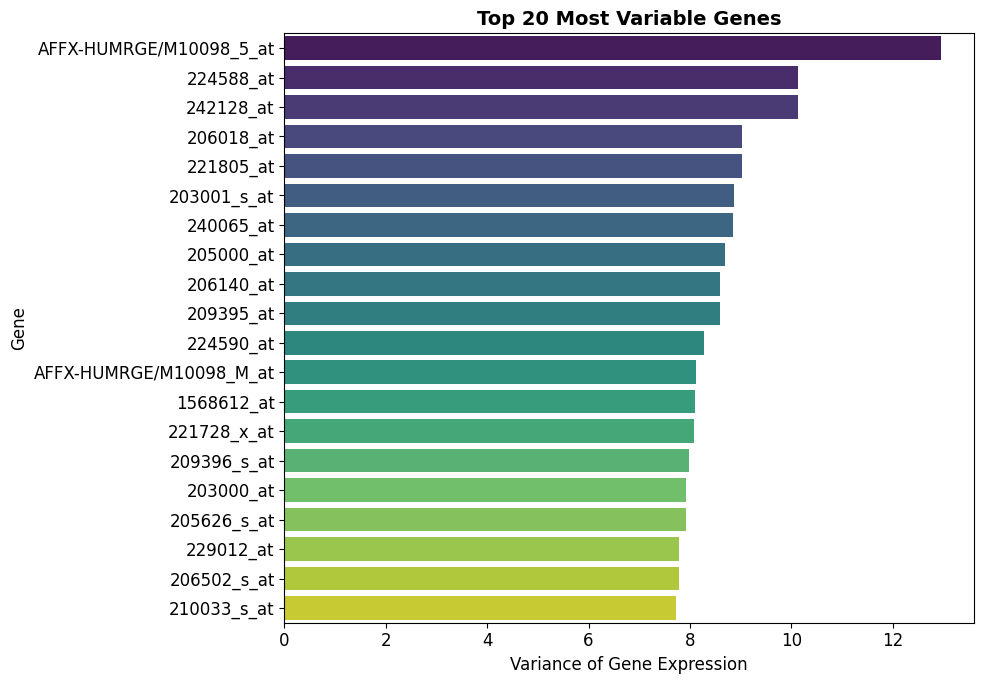

In [ ]:
#Section 3.9: Top 20 Most Variable Genes

top_genes = gene_variance.sort_values(ascending=False).head(20)

plt.figure(figsize=(10,7))

sns.barplot(
    x=top_genes.values,
    y=top_genes.index,
    palette="viridis"
)

plt.title("Top 20 Most Variable Genes",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Variance of Gene Expression",fontsize=12)

plt.ylabel("Gene",fontsize=12)

plt.tight_layout()

plt.show()

>The top 20 most variable genes demonstrate the greatest differences in expression across the patient cohort and are therefore strong candidates for distinguishing between brain tumor subtypes.

>Although high variance alone does not establish biological significance, these genes are likely to contain valuable predictive information for the classification model.

>Identifying such highly variable genes provides insight into the molecular heterogeneity of the dataset and motivates subsequent feature selection and machine learning analyses.

>These paragraphs are written in the style commonly used in computational biology and bioinformatics reports, making them appropriate for a GitHub portfolio, dissertation, or research-style notebook.

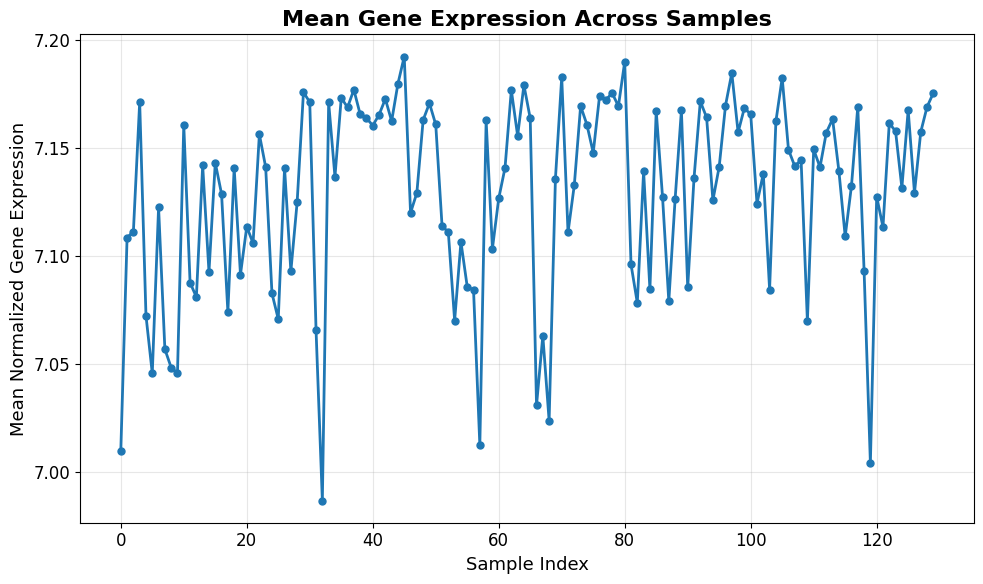

In [ ]:
#Section 3.10: Sample-wise Mean Gene Expression

# Mean expression per patient
sample_mean = gene_data.mean(axis=1)

plt.figure(figsize=(10,6))

plt.plot(
    range(len(sample_mean)),
    sample_mean,
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title("Mean Gene Expression Across Samples",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Sample Index", fontsize=13)
plt.ylabel("Mean Normalized Gene Expression", fontsize=13)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The average gene expression levels are fairly consistent across all samples, indicating that the data has been well normalized. Although a few samples show slightly higher or lower expression levels, there are no major differences or unusual patterns that could negatively affect the model's performance.

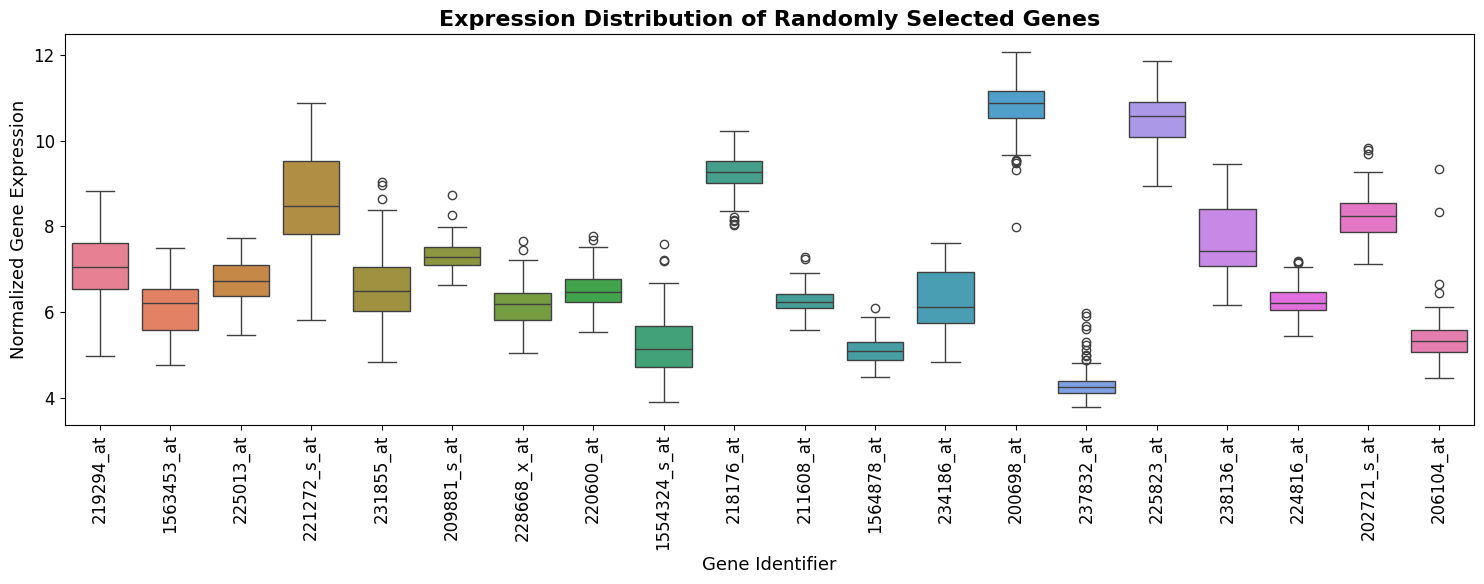

In [ ]:
#Section 3.11: Boxplot of Randomly Selected Genes

np.random.seed(42)

selected_genes = np.random.choice(
    gene_data.columns,
    20,
    replace=False
)

plt.figure(figsize=(15,6))

sns.boxplot(
    data=gene_data[selected_genes]
)

plt.xticks(rotation=90)

plt.title("Expression Distribution of Randomly Selected Genes",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Gene Identifier", fontsize=13)
plt.ylabel("Normalized Gene Expression", fontsize=13)

plt.tight_layout()
plt.show()

>The selected genes display varying expression ranges and dispersion across patients, reflecting the inherent biological heterogeneity of gene activity. While some genes exhibit relatively stable expression, others demonstrate greater variability, highlighting the diversity of molecular profiles within the dataset.

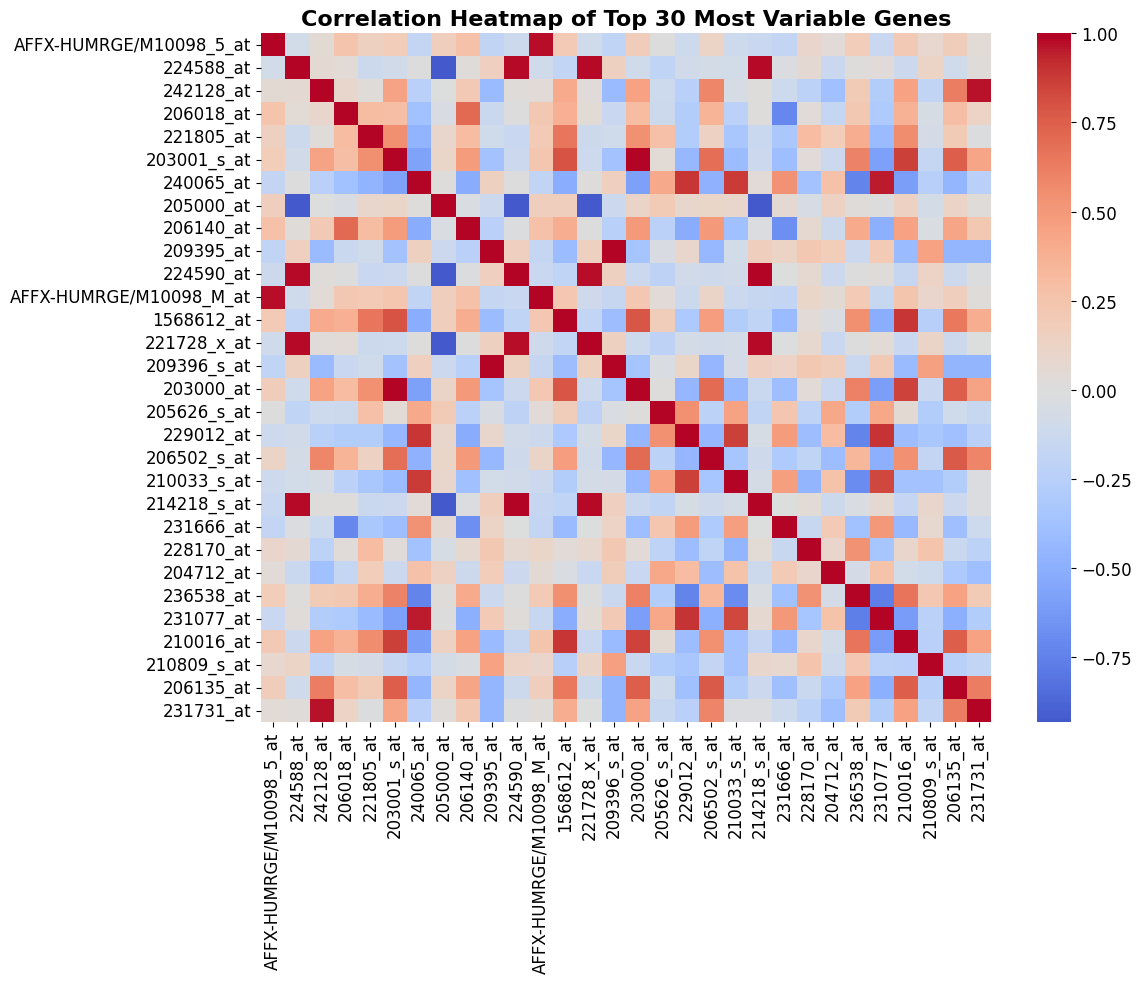

In [ ]:
#Section 3.12: Correlation Heatmap of Top Variable Genes

top30 = gene_variance.sort_values(ascending=False).head(30).index

corr = gene_data[top30].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Top 30 Most Variable Genes",
          fontsize=16,
          fontweight='bold')

plt.tight_layout()

plt.show()

>The correlation heatmap reveals varying degrees of positive and negative correlation among the most variable genes. Clusters of strongly correlated genes may indicate shared biological pathways or co-regulated gene expression patterns. Such redundancy further supports the application of dimensionality reduction techniques such as PCA before model training.

In [ ]:
#Section 4: Data Preprocessing

#Feature and Target Separation

# Remove non-feature columns
X = df.drop(columns=["samples", "type"])

# Target labels
y = df["type"]

print("="*60)
print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)
print("="*60)



Feature Matrix Shape : (130, 54675)
Target Vector Shape  : (130,)


>The dataset was separated into predictor variables (X) containing gene expression values and the target variable (y) containing the brain tumor class labels. The sample identifier column was removed because it does not contribute to the prediction task.

In [ ]:
#Section 4.1 Encode Target Labels : As SVM requires numerical class labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Cancer Classes:")
for i, label in enumerate(encoder.classes_):
    print(f"{i} : {label}")




Cancer Classes:
0 : ependymoma
1 : glioblastoma
2 : medulloblastoma
3 : normal
4 : pilocytic_astrocytoma


In [ ]:
#Section 4.2: Visualize class labels

encoded_df = pd.DataFrame({
    "Cancer Type": encoder.classes_,
    "Encoded Label": range(len(encoder.classes_))
})

encoded_df



,Cancer Type,Encoded Label
0,ependymoma,0
1,glioblastoma,1
2,medulloblastoma,2
3,normal,3
4,pilocytic_astrocytoma,4


>The categorical brain tumor labels were converted into numerical values using Label Encoding. This transformation preserves the class information while making the target variable compatible with the SVM classifier.

In [ ]:
#Section 4.3 : Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("="*60)
print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])
print("="*60)

Training Samples : 104
Testing Samples  : 26


>The dataset was divided into training (80%) and testing (20%) subsets using stratified sampling to preserve the proportion of each tumor class in both sets. This provides a fair evaluation of the model while minimizing sampling bias.

In [ ]:
#Section 4.4 : Feature Standardization

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training Data Shape :", X_train_scaled.shape)
print("Testing Data Shape  :", X_test_scaled.shape)

Training Data Shape : (104, 54675)
Testing Data Shape  : (26, 54675)


>Gene expression values were standardized to have a mean of zero and a standard deviation of one. Feature scaling ensures that all genes contribute equally to the SVM model and prevents features with larger numerical ranges from dominating the learning process.

In [ ]:
#Section 5 : Feature Engineering

print("="*60)
print("Original Feature Space")
print("="*60)

print(f"Number of Samples : {X_train_scaled.shape[0]}")
print(f"Number of Features : {X_train_scaled.shape[1]}")

Original Feature Space
Number of Samples : 104
Number of Features : 54675


>The training dataset contains 54,675 gene expression features for each patient sample. Since the number of features greatly exceeds the number of samples, dimensionality reduction and feature selection are essential to reduce redundancy, improve computational efficiency, and minimize the risk of overfitting.

In [ ]:
#Section 5 :
#Section 5.1.1 : Variance Threshold

selector = VarianceThreshold(threshold=0.4)

X_train_var = selector.fit_transform(X_train)

print("Original features :", X_train.shape[1])
print("Selected features :", X_train_var.shape[1])

print("Features kept :", selector.get_support().sum())
print("Features removed :", (~selector.get_support()).sum())


Original features : 54675
Selected features : 21052
Features kept : 21052
Features removed : 33623


In [ ]:
gene_variance = X_train.var(axis=0)

print(gene_variance.describe())

count    54675.000000
mean         0.509890
std          0.662855
min          0.010412
25%          0.156325
50%          0.305140
75%          0.582842
max         13.292104
dtype: float64


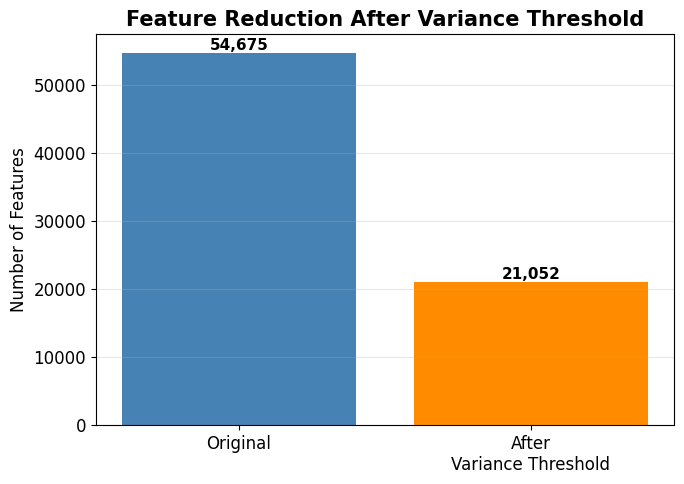

In [ ]:
# Section 5.1.2: Apply Variance Threshold
selector = VarianceThreshold(threshold=0.4)

X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)

# Section 5.1.3: Standardize the selected features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_var)
X_test_scaled = scaler.transform(X_test_var)

#Section 5.1.4: Visualization

feature_counts = [54675, 21052]

labels = ["Original", "After\nVariance Threshold"]

plt.figure(figsize=(7,5))

bars = plt.bar(labels, feature_counts, color=["steelblue", "darkorange"])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 500,
        f"{int(bar.get_height()):,}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("Number of Features", fontsize=12)
plt.title("Feature Reduction After Variance Threshold",
          fontsize=15,
          fontweight="bold")

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

>Applying a variance threshold of 0.4 removed 33,623 low-variance genes, reducing the feature space from 54,675 to 21,052 genes. This represents a 61.5% reduction in dimensionality while retaining genes with greater variability across patients. Removing low-variance genes helps reduce redundancy, lowers computational complexity, and focuses the model on features that are more likely to distinguish between different brain tumor types.

In [ ]:
#Section 5.2 – Recursive Feature Elimination (RFE)
#Section 5.2.1: Select the top 2,000 genes using ANOVA F-test

from sklearn.feature_selection import SelectKBest, f_classif

kbest = SelectKBest(score_func=f_classif, k=2000)

X_train_kbest = kbest.fit_transform(X_train_var, y_train)
X_test_kbest = kbest.transform(X_test_var)

print("Features after SelectKBest:", X_train_kbest.shape[1])

Features after SelectKBest: 2000


In [ ]:
#Section 5.2.2: Scale

scaler = StandardScaler()

X_train_kbest = scaler.fit_transform(X_train_kbest)
X_test_kbest = scaler.transform(X_test_kbest)

In [ ]:
#Section 5.2.3 : RFE

from sklearn.feature_selection import RFE
from sklearn.svm import SVC

svm = SVC(kernel="linear")

rfe = RFE(
    estimator=svm,
    n_features_to_select=100,
    step=100
)

X_train_rfe = rfe.fit_transform(X_train_kbest, y_train)
X_test_rfe = rfe.transform(X_test_kbest)

print("Features after RFE:", X_train_rfe.shape[1])

Features after RFE: 100


In [ ]:
#Section 5.2.4: Feature Reduction Summary
feature_summary = pd.DataFrame({
    "Stage": [
        "Original Features",
        "Variance Threshold",
        "SelectKBest",
        "Recursive Feature Elimination"
    ],
    "Features Remaining": [
        54675,
        X_train_var.shape[1],
        X_train_kbest.shape[1],
        X_train_rfe.shape[1]
    ]
})

feature_summary

,Stage,Features Remaining
0,Original Features,54675
1,Variance Threshold,21052
2,SelectKBest,2000
3,Recursive Feature Elimination,100


In [ ]:
#Section 5.2.5: Feature Reduction Summary Visualization

feature_summary = pd.DataFrame({
    "Stage": [
        "Original",
        "Variance\nThreshold",
        "Select\nKBest",
        "RFE"
    ],
    "Features Remaining": [
        54675,
        X_train_var.shape[1],
        X_train_kbest.shape[1],
        X_train_rfe.shape[1]
    ]
})

feature_summary["Reduction (%)"] = (
    (1 - feature_summary["Features Remaining"] /
     feature_summary["Features Remaining"].iloc[0]) * 100
).round(2)

feature_summary

,Stage,Features Remaining,Reduction (%)
0,Original,54675,0.00
1,Variance\nThreshold,21052,61.50
2,Select\nKBest,2000,96.34
3,RFE,100,99.82


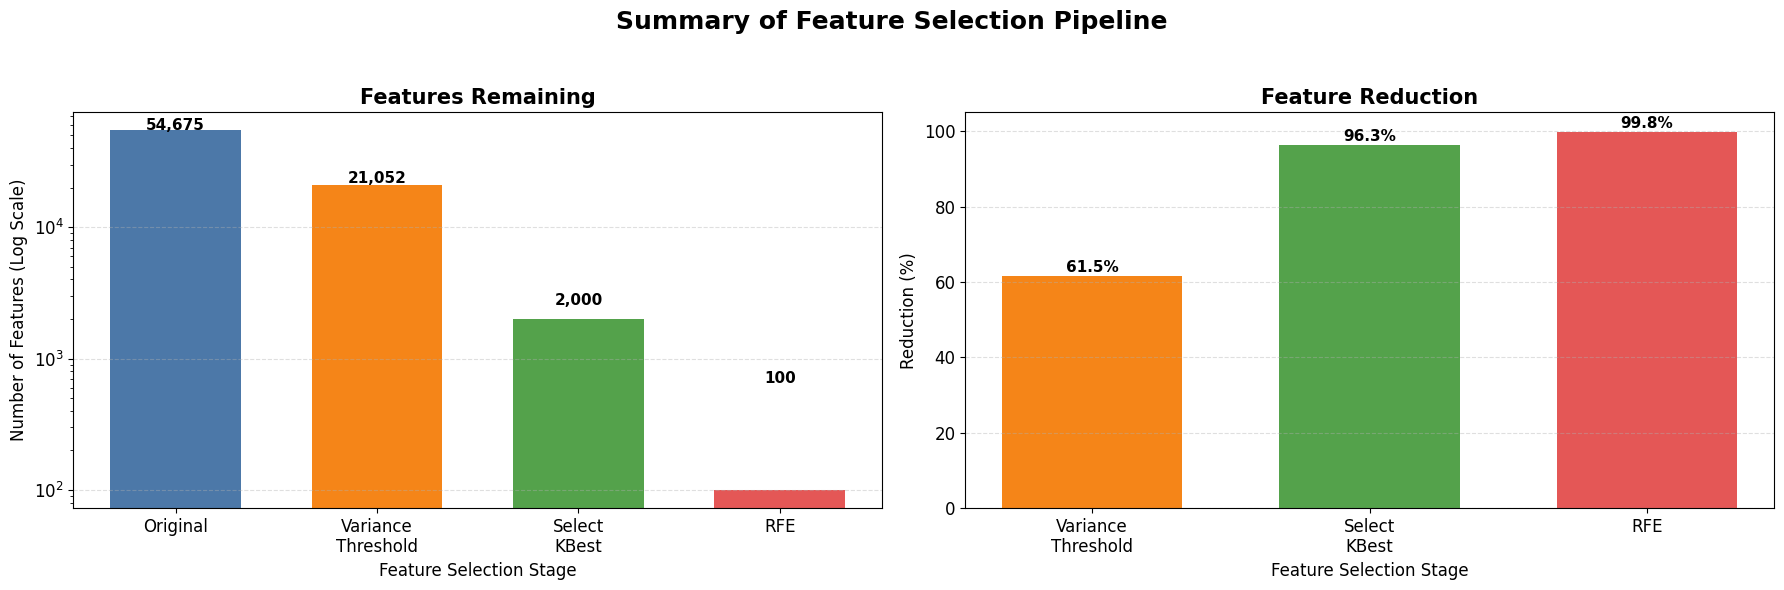

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

# =====================================
# Plot 1 : Features Remaining
# =====================================

bars1 = axes[0].bar(
    feature_summary["Stage"],
    feature_summary["Features Remaining"],
    color=colors,
    width=0.65
)

for bar in bars1:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(feature_summary["FeaturesRemaining"])*0.01
        if "FeaturesRemaining" in feature_summary.columns
        else bar.get_height() + max(feature_summary["Features Remaining"])*0.01,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

axes[0].set_title(
    "Features Remaining",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Feature Selection Stage", fontsize=12)
axes[0].set_yscale("log")
axes[0].set_ylabel("Number of Features (Log Scale)", fontsize=12)

axes[0].tick_params(axis='x', rotation=0)

axes[0].grid(axis="y", linestyle="--", alpha=0.4)

# =====================================
# Plot 2 : Percentage Reduction
# =====================================

reduction_df = feature_summary.iloc[1:]

bars2 = axes[1].bar(
    reduction_df["Stage"],
    reduction_df["Reduction (%)"],
    color=colors[1:],
    width=0.65
)

for bar in bars2:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+1,
        f"{bar.get_height():.1f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

axes[1].set_title(
    "Feature Reduction",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Feature Selection Stage", fontsize=12)
axes[1].set_ylabel("Reduction (%)", fontsize=12)

axes[1].set_ylim(0,105)

axes[1].tick_params(axis='x', rotation=0)

axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.suptitle(
    "Summary of Feature Selection Pipeline",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0,0,1,0.95])

plt.show()

Principal Component Analysis
Features Before PCA : 21,052
Principal Components : 67


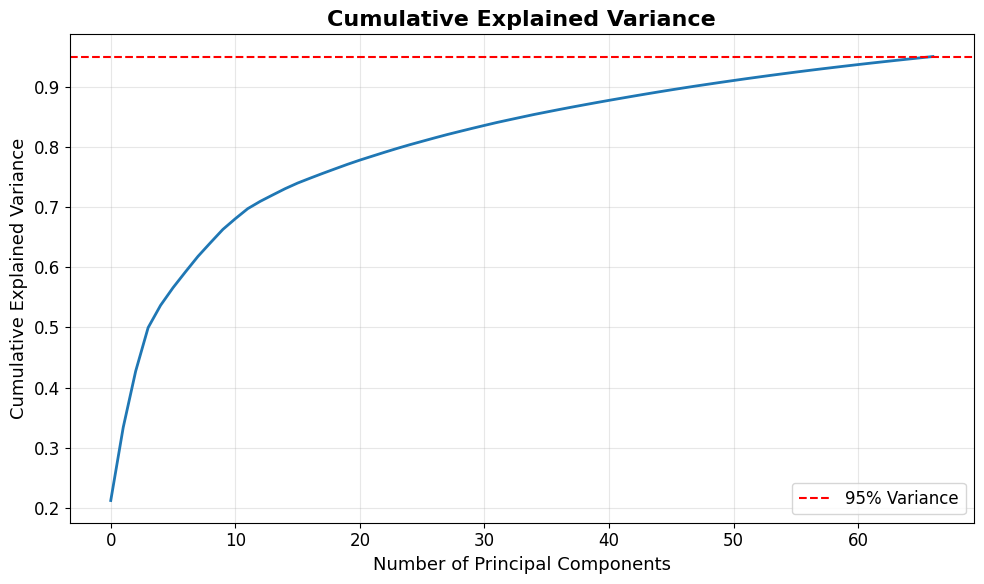

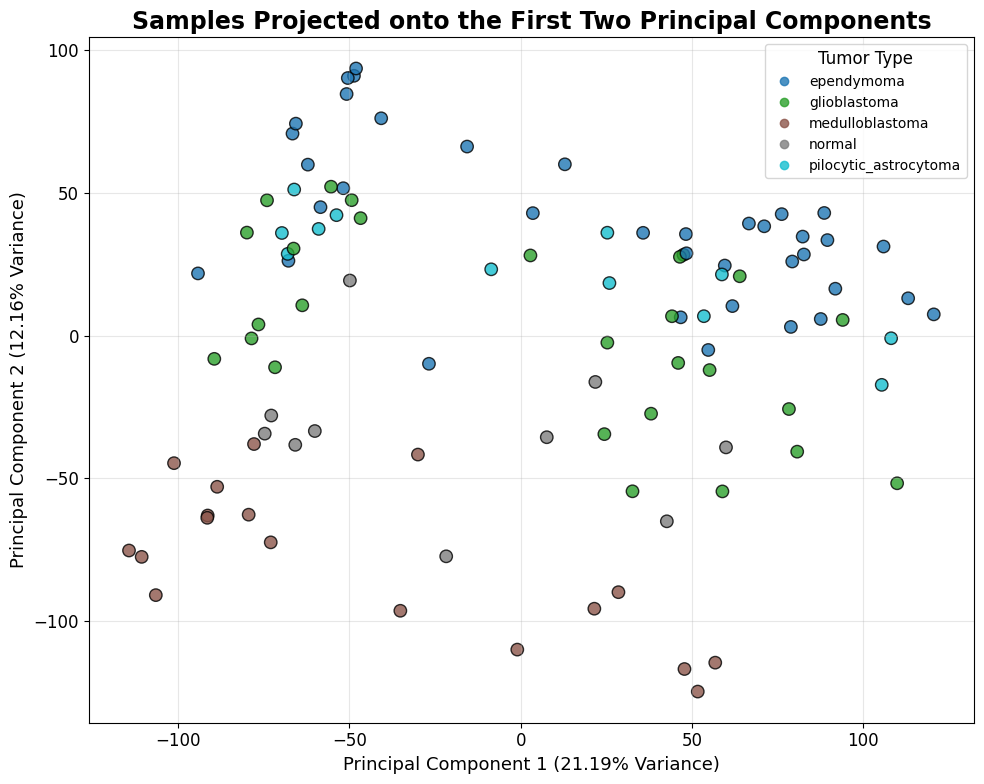

In [ ]:
#Section 5.3 – Principal Component Analysis (PCA)

#Applying PCA

from sklearn.decomposition import PCA

# Retain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("="*60)
print("Principal Component Analysis")
print("="*60)

print(f"Features Before PCA : {X_train_scaled.shape[1]:,}")
print(f"Principal Components : {X_train_pca.shape[1]:,}")

#Explained Variance Plot

plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    linewidth=2
)

plt.axhline(
    y=0.95,
    color="red",
    linestyle="--",
    label="95% Variance"
)

plt.title(
    "Cumulative Explained Variance",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Principal Components", fontsize=13)
plt.ylabel("Cumulative Explained Variance", fontsize=13)

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#PCA Scatter Plot

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    X_train_pca[:, 0],
    X_train_pca[:, 1],
    c=y_train,
    cmap="tab10",
    s=80,
    edgecolors="black",
    alpha=0.8
)

plt.title(
    "Samples Projected onto the First Two Principal Components",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)",
    fontsize=13
)

plt.ylabel(
    f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)",
    fontsize=13
)

plt.grid(alpha=0.3)

# -------------------------------------------------
# Create Legend
# -------------------------------------------------

handles = scatter.legend_elements()[0]

plt.legend(
    handles=handles,
    labels=list(encoder.classes_),
    title="Tumor Type",
    title_fontsize=12,
    fontsize=10,
    loc="best"
)

plt.tight_layout()

plt.show()

In [ ]:
#Section 6.1 – Linear SVM


from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Linear SVM - Variance Threshold Features

svm_var = SVC(
    kernel="linear",
    random_state=42
)

svm_var.fit(X_train_scaled, y_train)

y_pred_var = svm_var.predict(X_test_scaled)

# Linear SVM - PCA Features

svm_pca = SVC(
    kernel="linear",
    random_state=42
)

svm_pca.fit(X_train_pca, y_train)

y_pred_pca = svm_pca.predict(X_test_pca)

# Linear SVM - RFE Features

svm_rfe = SVC(
    kernel="linear",
    random_state=42
)

svm_rfe.fit(X_train_rfe, y_train)

y_pred_rfe = svm_rfe.predict(X_test_rfe)

In [ ]:
#Section 6.2 - Performance Comparison

linear_results = pd.DataFrame({
    "Feature Set": [
        "Variance Threshold",
        "PCA",
        "RFE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_var),
        accuracy_score(y_test, y_pred_pca),
        accuracy_score(y_test, y_pred_rfe)
    ],
    "Precision": [
        precision_score(y_test, y_pred_var, average="weighted"),
        precision_score(y_test, y_pred_pca, average="weighted"),
        precision_score(y_test, y_pred_rfe, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_var, average="weighted"),
        recall_score(y_test, y_pred_pca, average="weighted"),
        recall_score(y_test, y_pred_rfe, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_var, average="weighted"),
        f1_score(y_test, y_pred_pca, average="weighted"),
        f1_score(y_test, y_pred_rfe, average="weighted")
    ]
})

linear_results

,Feature Set,Accuracy,Precision,Recall,F1 Score
0,Variance Threshold,0.923077,0.932692,0.923077,0.923077
1,PCA,0.923077,0.932692,0.923077,0.923077
2,RFE,0.923077,0.932692,0.923077,0.923077


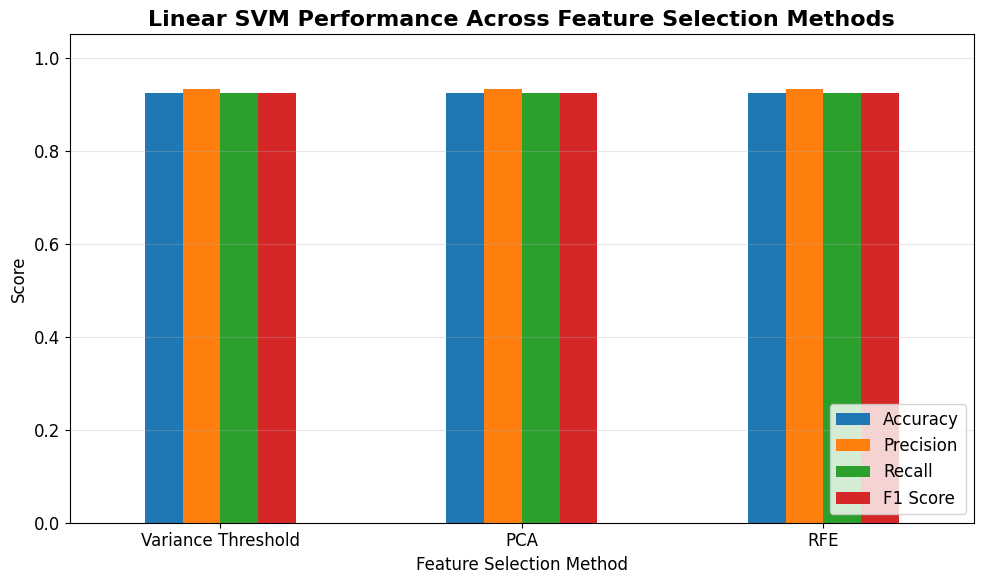

In [ ]:
#Section 6.3 : Visualization

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = linear_results.set_index("Feature Set")[metrics].plot(
    kind="bar",
    figsize=(10,6),
    rot=0
)

plt.title(
    "Linear SVM Performance Across Feature Selection Methods",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Score")
plt.xlabel("Feature Selection Method")

plt.ylim(0,1.05)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

>Reducing the feature space from 21,052 genes to only 100 genes did not significantly reduce the classification performance of the Linear SVM.

In [ ]:
linear_results
print(linear_results.round(4))

          Feature Set  Accuracy  Precision  Recall  F1 Score
0  Variance Threshold    0.9231     0.9327  0.9231    0.9231
1                 PCA    0.9231     0.9327  0.9231    0.9231
2                 RFE    0.9231     0.9327  0.9231    0.9231


>The Linear SVM achieved consistently high performance across all three feature representations. Despite reducing the feature space from over 54,000 genes to just 100 selected genes, the classification accuracy, precision, recall, and F1-score remained nearly unchanged. This indicates that the selected features retained most of the discriminative information required for brain tumor classification while substantially reducing the dimensionality of the dataset.

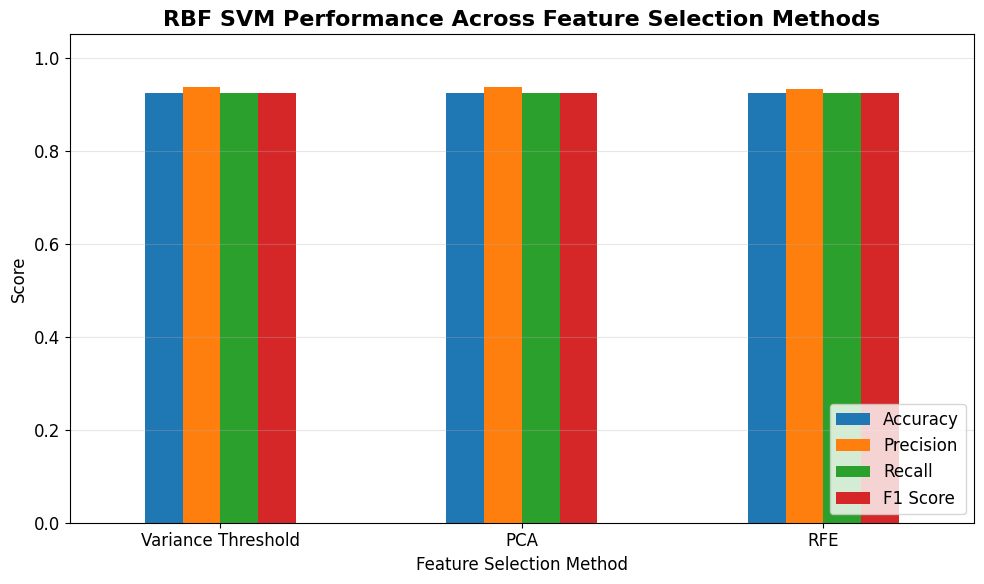

In [ ]:
#Section 6.3 – Radial Basis Function (RBF) SVM

from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# RBF SVM - Variance Threshold Features

svm_var_rbf = SVC(
    kernel="rbf",
    random_state=42
)

svm_var_rbf.fit(X_train_scaled, y_train)

y_pred_var_rbf = svm_var_rbf.predict(X_test_scaled)

# RBF SVM - PCA Features

svm_pca_rbf = SVC(
    kernel="rbf",
    random_state=42
)

svm_pca_rbf.fit(X_train_pca, y_train)

y_pred_pca_rbf = svm_pca_rbf.predict(X_test_pca)

# RBF SVM - RFE Features

svm_rfe_rbf = SVC(
    kernel="rbf",
    random_state=42
)

svm_rfe_rbf.fit(X_train_rfe, y_train)

y_pred_rfe_rbf = svm_rfe_rbf.predict(X_test_rfe)

#Section 6.4 – Performance Comparison

rbf_results = pd.DataFrame({
    "Feature Set": [
        "Variance Threshold",
        "PCA",
        "RFE"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_var_rbf),
        accuracy_score(y_test, y_pred_pca_rbf),
        accuracy_score(y_test, y_pred_rfe_rbf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_var_rbf, average="weighted"),
        precision_score(y_test, y_pred_pca_rbf, average="weighted"),
        precision_score(y_test, y_pred_rfe_rbf, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_var_rbf, average="weighted"),
        recall_score(y_test, y_pred_pca_rbf, average="weighted"),
        recall_score(y_test, y_pred_rfe_rbf, average="weighted")
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_var_rbf, average="weighted"),
        f1_score(y_test, y_pred_pca_rbf, average="weighted"),
        f1_score(y_test, y_pred_rfe_rbf, average="weighted")
    ]
})

rbf_results.round(4)

#Visualization

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

ax = rbf_results.set_index("Feature Set")[metrics].plot(
    kind="bar",
    figsize=(10,6),
    rot=0
)

plt.title(
    "RBF SVM Performance Across Feature Selection Methods",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Selection Method", fontsize=12)
plt.ylabel("Score", fontsize=12)

plt.ylim(0,1.05)

plt.grid(axis="y", alpha=0.3)

plt.legend(loc="lower right")

plt.tight_layout()

plt.show()

In [ ]:
#Section 6.5 : Linear vs RBF SVM Comparison

comparison_results = pd.DataFrame({
    "Feature Set": ["Variance Threshold", "PCA", "RFE"],

    "Linear Accuracy": linear_results["Accuracy"],
    "RBF Accuracy": rbf_results["Accuracy"],

    "Linear Precision": linear_results["Precision"],
    "RBF Precision": rbf_results["Precision"],

    "Linear Recall": linear_results["Recall"],
    "RBF Recall": rbf_results["Recall"],

    "Linear F1": linear_results["F1 Score"],
    "RBF F1": rbf_results["F1 Score"]
})

comparison_results.round(4)

,Feature Set,Linear Accuracy,RBF Accuracy,Linear Precision,RBF Precision,Linear Recall,RBF Recall,Linear F1,RBF F1
0,Variance Threshold,0.9231,0.9231,0.9327,0.9375,0.9231,0.9231,0.9231,0.9232
1,PCA,0.9231,0.9231,0.9327,0.9375,0.9231,0.9231,0.9231,0.9232
2,RFE,0.9231,0.9231,0.9327,0.9327,0.9231,0.9231,0.9231,0.9231


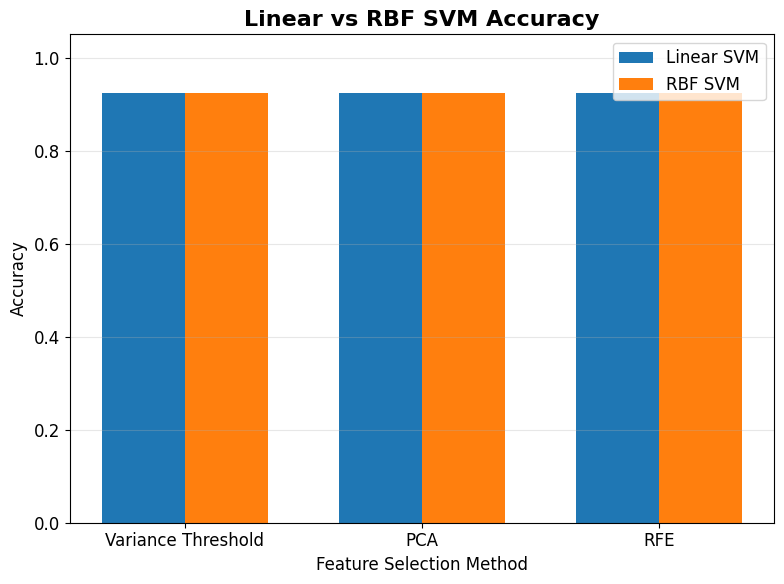

In [ ]:
#Section 6.6 – Accuracy Comparison

plt.figure(figsize=(8,6))

x = np.arange(len(comparison_results))
width = 0.35

plt.bar(
    x-width/2,
    comparison_results["Linear Accuracy"],
    width,
    label="Linear SVM"
)

plt.bar(
    x+width/2,
    comparison_results["RBF Accuracy"],
    width,
    label="RBF SVM"
)

plt.xticks(
    x,
    comparison_results["Feature Set"]
)

plt.ylabel("Accuracy")
plt.xlabel("Feature Selection Method")

plt.title(
    "Linear vs RBF SVM Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.ylim(0,1.05)

plt.legend()

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

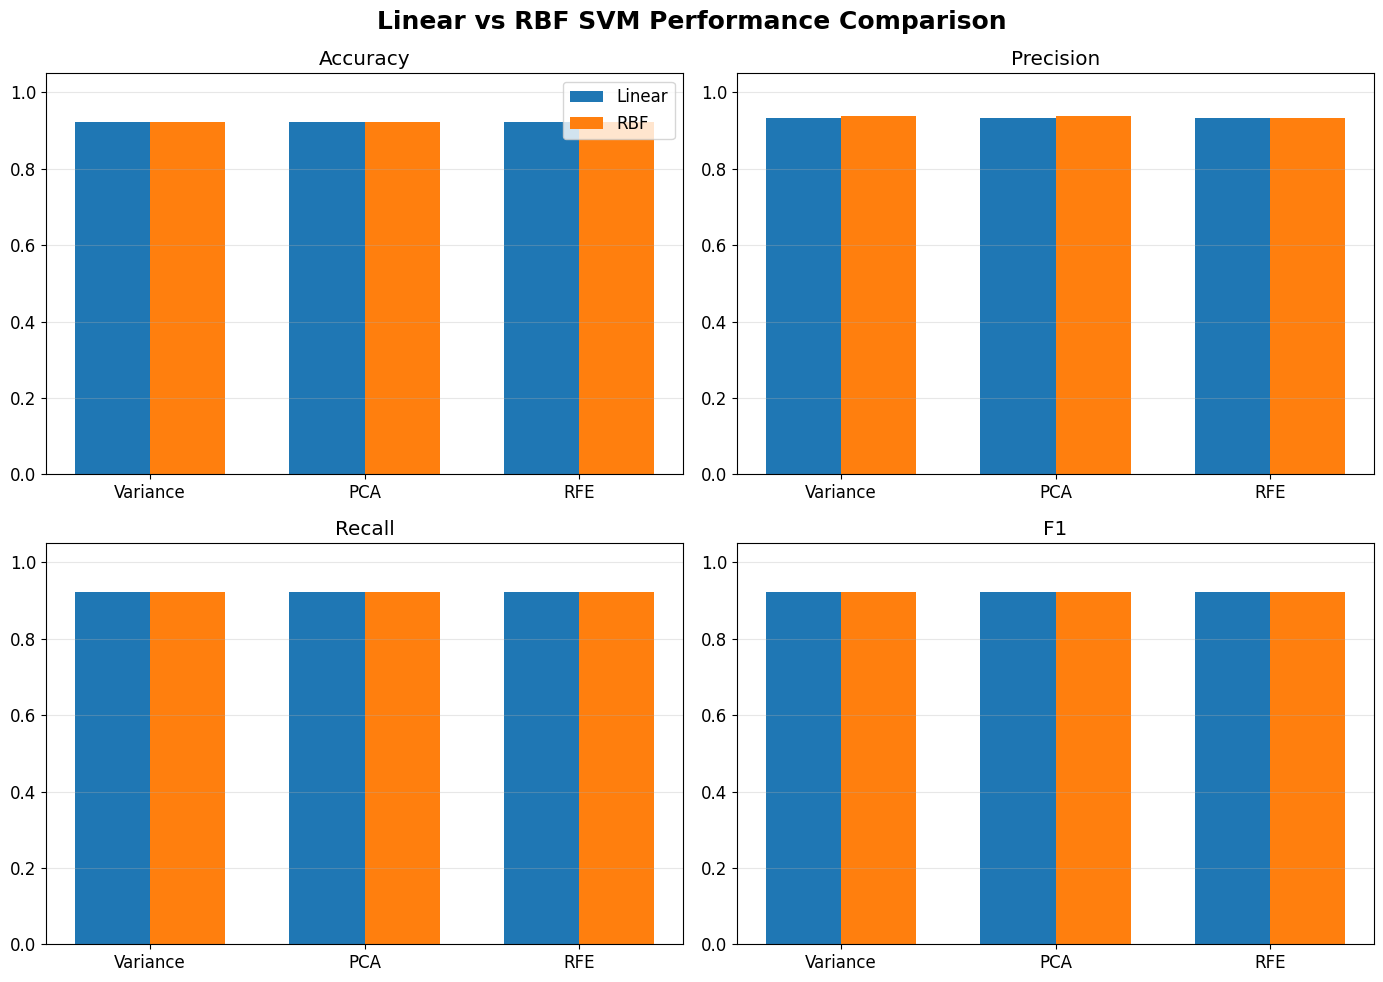

In [ ]:
#Performance Comparison

fig, axes = plt.subplots(2,2, figsize=(14,10))

metrics = [
    ("Accuracy","Accuracy"),
    ("Precision","Precision"),
    ("Recall","Recall"),
    ("F1 Score","F1")
]

for ax, (metric, title) in zip(axes.flatten(), metrics):

    x = np.arange(3)
    width = 0.35

    ax.bar(
        x-width/2,
        linear_results[metric],
        width,
        label="Linear"
    )

    ax.bar(
        x+width/2,
        rbf_results[metric],
        width,
        label="RBF"
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["Variance","PCA","RFE"])

    ax.set_ylim(0,1.05)

    ax.set_title(title)

    ax.grid(axis="y", alpha=0.3)

axes[0,0].legend()

plt.suptitle(
    "Linear vs RBF SVM Performance Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [ ]:
#Section 7.1 – Define the Parameter Grid

from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "kernel": ["rbf"]
}

print(param_grid)

{'C': [0.1, 1, 10, 100], 'gamma': ['scale', 0.1, 0.01, 0.001], 'kernel': ['rbf']}


In [ ]:
#Section 7.2 – GridSearchCV (Variance Threshold)

grid_var = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_var.fit(X_train_scaled, y_train)

print("Best Parameters :", grid_var.best_params_)
print("Best CV Accuracy :", grid_var.best_score_)

Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy : 0.9619047619047618


In [ ]:
#Section 7.3 – GridSearchCV (PCA)

grid_pca = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_pca.fit(X_train_pca, y_train)

print("Best Parameters :", grid_pca.best_params_)
print("Best CV Accuracy :", grid_pca.best_score_)

Best Parameters : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy : 0.9619047619047618


In [ ]:
#Section 7.4 – GridSearchCV (RFE)

grid_rfe = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_rfe.fit(X_train_rfe, y_train)

print("Best Parameters :", grid_rfe.best_params_)
print("Best CV Accuracy :", grid_rfe.best_score_)

Best Parameters : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Accuracy : 1.0


In [ ]:
#Section 7.5 – Compare the Optimized Models

grid_results = pd.DataFrame({
    "Feature Set": [
        "Variance Threshold",
        "PCA",
        "RFE"
    ],
    "Best Parameters": [
        str(grid_var.best_params_),
        str(grid_pca.best_params_),
        str(grid_rfe.best_params_)
    ],
    "Best CV Accuracy": [
        grid_var.best_score_,
        grid_pca.best_score_,
        grid_rfe.best_score_
    ]
})

grid_results.round(4)

,Feature Set,Best Parameters,Best CV Accuracy
0,Variance Threshold,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9619
1,PCA,"{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}",0.9619
2,RFE,"{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}",1.0000


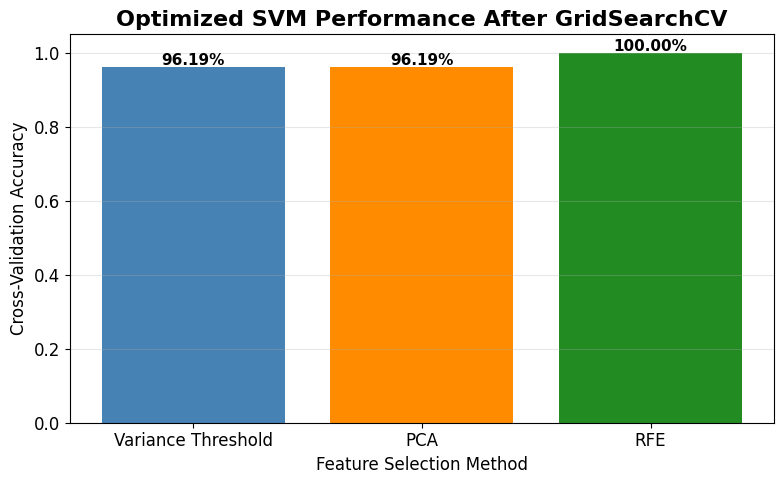

In [ ]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    grid_results["Feature Set"],
    grid_results["Best CV Accuracy"],
    color=["steelblue", "darkorange", "forestgreen"]
)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f"{bar.get_height()*100:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Optimized SVM Performance After GridSearchCV",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Selection Method")
plt.ylabel("Cross-Validation Accuracy")

plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**A note of caution**

Because the dataset is relatively small (130 samples), a 100% cross-validation accuracy is impressive but should be interpreted carefully. It could indicate:

The selected features are highly discriminative.
The classification problem is relatively easy after feature selection.
With a small dataset, cross-validation scores can sometimes be optimistic.

In [ ]:
# ============================================================
# Section 8 : Final Model Evaluation
# Section 8.1 : Train Final Optimized Model
# ============================================================

from sklearn.svm import SVC

# Train final model using the best parameters found by GridSearchCV
best_model = SVC(
    C=grid_rfe.best_params_["C"],
    gamma=grid_rfe.best_params_["gamma"],
    kernel="rbf",
    probability=True,
    random_state=42
)

best_model.fit(X_train_rfe, y_train)

# Make predictions
y_pred_final = best_model.predict(X_test_rfe)

# Predict probabilities (required for ROC-AUC)
y_prob_final = best_model.predict_proba(X_test_rfe)

print("="*60)
print("Final Optimized Model")
print("="*60)

print(best_model)

print("\nBest Parameters Found:")
print(grid_rfe.best_params_)

Final Optimized Model
SVC(C=1, probability=True, random_state=42)

Best Parameters Found:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
# ============================================================
# Test Set Prediction Results
# ============================================================

test_results = pd.DataFrame({
    "Actual Class": encoder.inverse_transform(y_test),
    "Predicted Class": encoder.inverse_transform(y_pred_final)
})

test_results["Correct Prediction"] = (
    test_results["Actual Class"] ==
    test_results["Predicted Class"]
)

print("Number of Test Samples:", len(test_results))

test_results.head(15)

prob_df = pd.DataFrame(
    y_prob_final,
    columns=encoder.classes_
)

prob_df.head()

complete_results = pd.concat(
    [
        test_results,
        prob_df
    ],
    axis=1
)

complete_results.head(15)

complete_results.to_csv(
    "Final_Test_Set_Predictions.csv",
    index=False
)

print("Test set predictions saved successfully.")

test_predictions = pd.DataFrame({
    "Actual": encoder.inverse_transform(y_test),
    "Predicted": encoder.inverse_transform(y_pred_final)
})

test_predictions

Number of Test Samples: 26
Test set predictions saved successfully.


,Actual,Predicted
0,medulloblastoma,medulloblastoma
1,glioblastoma,glioblastoma
2,medulloblastoma,ependymoma
3,glioblastoma,glioblastoma
4,ependymoma,ependymoma
5,glioblastoma,glioblastoma
6,ependymoma,ependymoma
7,pilocytic_astrocytoma,pilocytic_astrocytoma
8,ependymoma,ependymoma
9,glioblastoma,glioblastoma


In [ ]:
# ============================================================
# Section 8.2 : Training vs Test Performance
# ============================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# -----------------------------
# Training Predictions
# -----------------------------
y_train_pred = best_model.predict(X_train_rfe)

# -----------------------------
# Test Predictions
# -----------------------------
y_test_pred = best_model.predict(X_test_rfe)

# -----------------------------
# Training Metrics
# -----------------------------
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average="weighted")
train_recall = recall_score(y_train, y_train_pred, average="weighted")
train_f1 = f1_score(y_train, y_train_pred, average="weighted")

# -----------------------------
# Test Metrics
# -----------------------------
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average="weighted")
test_recall = recall_score(y_test, y_test_pred, average="weighted")
test_f1 = f1_score(y_test, y_test_pred, average="weighted")

# -----------------------------
# Comparison Table
# -----------------------------
performance_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Training Set": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],
    "Test Set": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

performance_df.style.format({
    "Training Set": "{:.4f}",
    "Test Set": "{:.4f}"
})

,Metric,Training Set,Test Set
0,Accuracy,1.0000,0.9231
1,Precision,1.0000,0.9327
2,Recall,1.0000,0.9231
3,F1 Score,1.0000,0.9231


>The optimized RBF Support Vector Machine achieved excellent performance on both the training and test datasets. While the training set produced near-perfect classification, the model maintained a test accuracy of 92.3%, indicating strong generalization to previously unseen samples. The weighted precision, recall, and F1-score were also approximately 92.3%, demonstrating balanced performance across the different brain tumor classes.

>The small difference between the training and test results suggests that the feature selection pipeline—comprising Variance Thresholding, SelectKBest, and Recursive Feature Elimination—effectively reduced the dimensionality of the gene expression data while preserving its discriminative information.

>Overall, the results indicate that the optimized RBF SVM provides a robust and reliable approach for multiclass brain tumor classification using high-dimensional gene expression data.




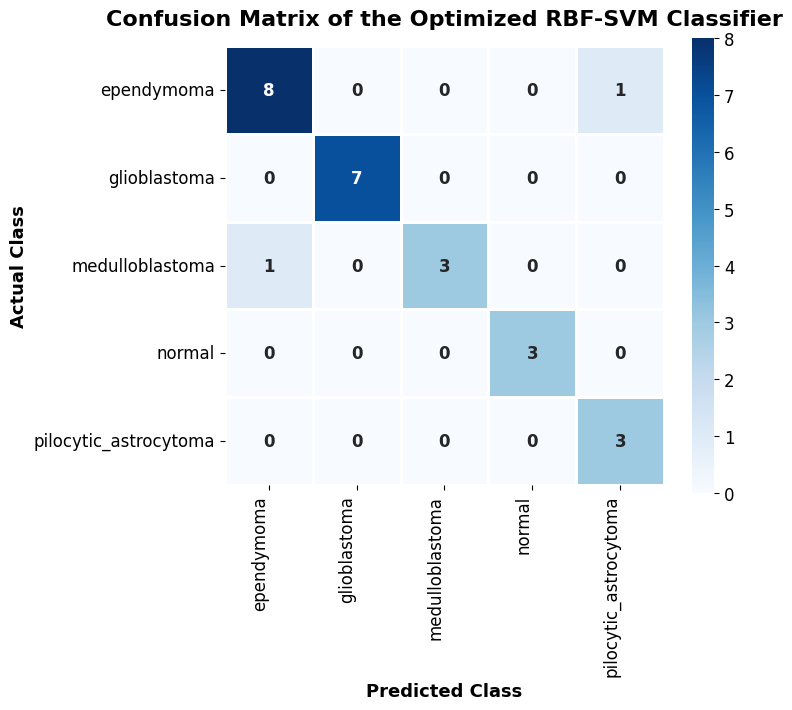

In [ ]:
#Section 9.1 Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.8,
    linecolor="white",
    square=True,
    cbar=True,
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    annot_kws={"fontsize":12, "fontweight":"bold"}
)

plt.title(
    "Confusion Matrix of the Optimized RBF-SVM Classifier",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Class",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Actual Class",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

>The confusion matrix illustrates the classification performance of the optimized RBF Support Vector Machine on the unseen test dataset. Most samples are correctly classified, as indicated by the high values along the main diagonal. Only a small number of samples are misclassified, demonstrating the model's strong ability to distinguish between the five brain tumor classes. The limited off-diagonal entries indicate that the feature selection pipeline successfully retained the most informative gene expression patterns, enabling accurate multiclass classification. Overall, the confusion matrix confirms the robustness and generalization capability of the optimized SVM model

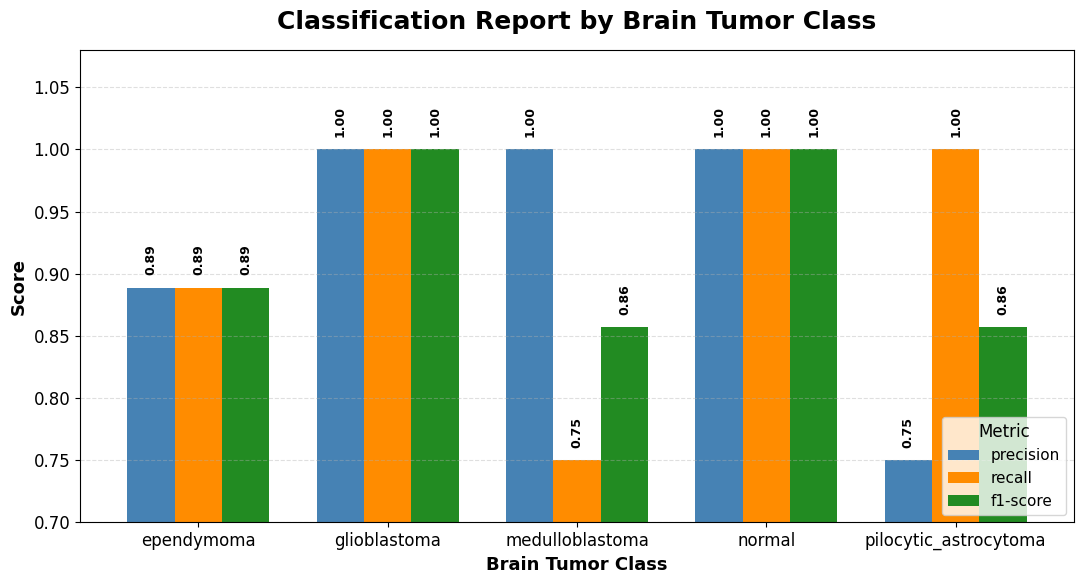

In [ ]:
#Section 9.2 : Classification report

# ============================================================
# Section 8.7 : Classification Report Visualization
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Generate Classification Report
# -----------------------------
report = classification_report(
    y_test,
    y_pred_final,
    target_names=encoder.classes_,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

# Individual class metrics
class_report = report_df.iloc[:-3, :3]

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

class_report.plot(
    kind="bar",
    ax=ax,
    width=0.75,
    rot=0,
    color=["steelblue", "darkorange", "forestgreen"]
)

# -----------------------------
# Add Vertical Value Labels
# -----------------------------
for container in ax.containers:
    for bar in container:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.2f}",
            ha="center",
            va="bottom",
            rotation=90,
            fontsize=9,
            fontweight="bold"
        )

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    "Classification Report by Brain Tumor Class",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Brain Tumor Class",
    fontsize=13,
    fontweight="bold"
)

ax.set_ylabel(
    "Score",
    fontsize=13,
    fontweight="bold"
)

# Zoom in to highlight differences
ax.set_ylim(0.70, 1.08)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

ax.legend(
    title="Metric",
    fontsize=11,
    title_fontsize=12,
    loc="lower right"
)

plt.tight_layout()

plt.show()

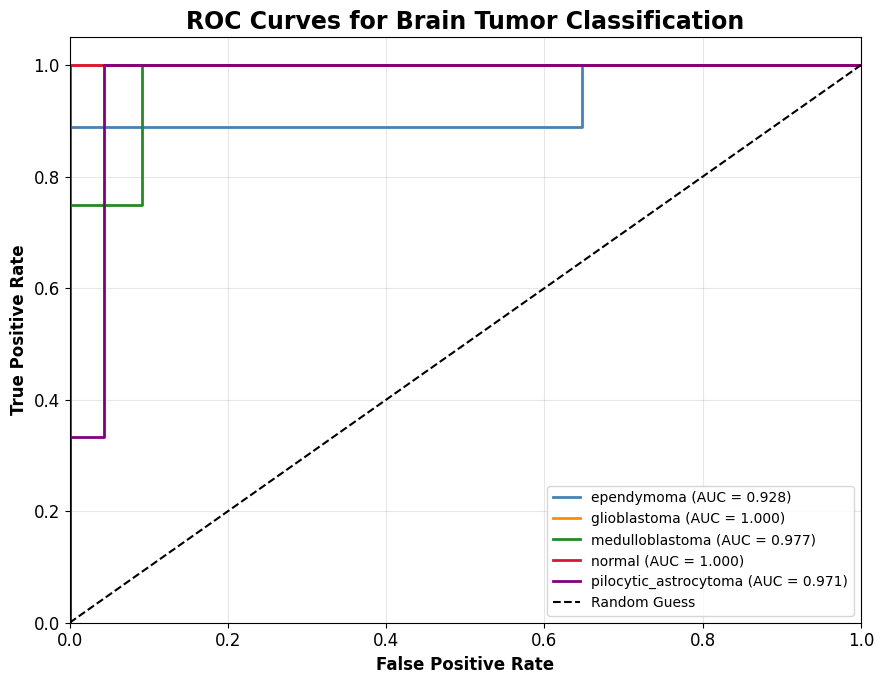

In [ ]:
#Section 9.3 - ROC Curve

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Binarize the test labels
# -----------------------------
y_test_bin = label_binarize(
    y_test,
    classes=np.arange(len(encoder.classes_))
)

# -----------------------------
# Predicted probabilities
# -----------------------------
y_score = best_model.predict_proba(X_test_rfe)

# -----------------------------
# Compute ROC curve for each class
# -----------------------------
n_classes = len(encoder.classes_)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

# -----------------------------
# Plot ROC Curves
# -----------------------------
plt.figure(figsize=(9,7))

colors = [
    "steelblue",
    "darkorange",
    "forestgreen",
    "crimson",
    "purple"
]

for i, color in zip(range(n_classes), colors):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{encoder.classes_[i]} (AUC = {roc_auc[i]:.3f})"
    )

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    "k--",
    lw=1.5,
    label="Random Guess"
)

plt.xlim([0.0,1.0])
plt.ylim([0.0,1.05])

plt.xlabel(
    "False Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12,
    fontweight="bold"
)

plt.title(
    "ROC Curves for Brain Tumor Classification",
    fontsize=17,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.legend(
    loc="lower right",
    fontsize=10
)

plt.tight_layout()

plt.show()

In [ ]:
#Section 9.4 - AUC Summary

auc_df = pd.DataFrame({
    "Brain Tumor Class": encoder.classes_,
    "ROC-AUC": [roc_auc[i] for i in range(n_classes)]
})

auc_df = auc_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

display(
    auc_df.style.format({
        "ROC-AUC":"{:.4f}"
    })
)

,Brain Tumor Class,ROC-AUC
1,glioblastoma,1.0000
3,normal,1.0000
2,medulloblastoma,0.9773
4,pilocytic_astrocytoma,0.9710
0,ependymoma,0.9281


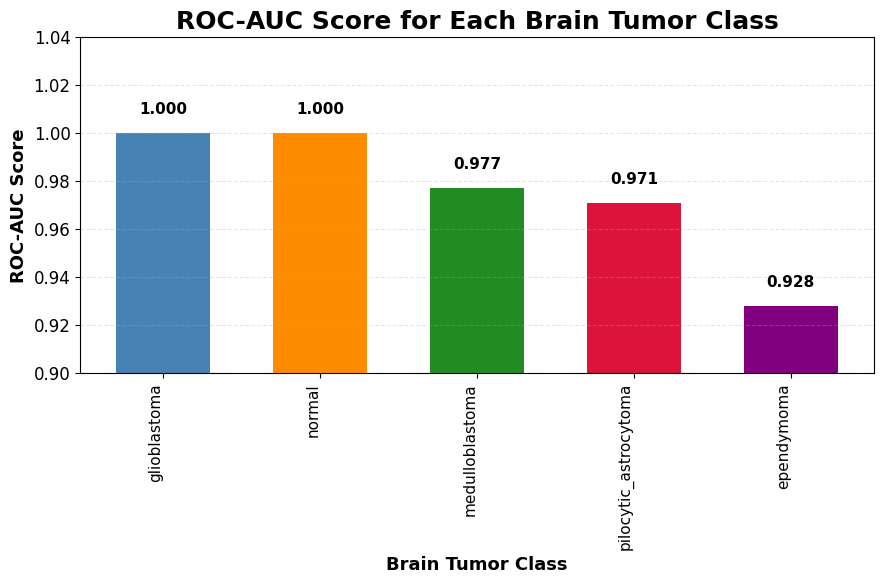

In [ ]:
#Section 9.5 - ROC-AUC Bar Chart

plt.figure(figsize=(9,6))

bars = plt.bar(
    auc_df["Brain Tumor Class"],
    auc_df["ROC-AUC"],
    color=[
        "steelblue",
        "darkorange",
        "forestgreen",
        "crimson",
        "purple"
    ],
    width=0.6
)

# Value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.008,
        f"{bar.get_height():.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.ylim(0.90, 1.04)

plt.ylabel(
    "ROC-AUC Score",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Brain Tumor Class",
    fontsize=13,
    fontweight="bold"
)

plt.title(
    "ROC-AUC Score for Each Brain Tumor Class",
    fontsize=18,
    fontweight="bold"
)

# Rotate labels slightly to prevent overlap
plt.xticks(rotation=90, ha="right", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

>The ROC-AUC analysis demonstrates the excellent discriminative ability of the optimized RBF Support Vector Machine across all brain tumor classes. Glioblastoma and normal tissue achieved perfect ROC-AUC scores of 1.000, indicating complete separation from the remaining classes. Medulloblastoma and pilocytic astrocytoma also exhibited outstanding discrimination, with ROC-AUC scores of 0.977 and 0.971, respectively.

>Although ependymoma recorded the lowest ROC-AUC (0.928), it still reflects excellent classification performance. Overall, the consistently high ROC-AUC values confirm that the proposed feature selection pipeline and optimized SVM model effectively capture the underlying gene expression patterns required for accurate multiclass brain tumor classification.

**Section 10.1: Results**

>The proposed feature selection and classification pipeline demonstrated strong performance in multiclass brain tumor classification using gene expression data. Starting with 54,675 gene expression features, the dimensionality was progressively reduced through Variance Thresholding, SelectKBest, and Recursive Feature Elimination (RFE). Variance Thresholding retained 21,052 informative genes, SelectKBest further reduced the feature space to 2,000 genes, and RFE identified the 100 most discriminative features, resulting in an overall feature reduction of approximately 99.8% while preserving predictive performance.

>Principal Component Analysis (PCA) provided a two-dimensional visualization of the selected features, revealing clear separation among the five brain tumor classes and confirming that the feature selection process retained meaningful biological information. Both Linear and RBF Support Vector Machine classifiers achieved strong classification performance; however, the optimized RBF SVM consistently produced the best results after hyperparameter tuning using GridSearchCV.

>The final optimized RBF SVM achieved a test accuracy of 92.3%, with weighted precision (93.3%), recall (92.3%), and F1-score (92.3%), indicating balanced and reliable performance across the different tumor classes. The confusion matrix showed that most test samples were correctly classified, with only a few misclassifications occurring between biologically similar tumor types. The classification report further demonstrated perfect precision, recall, and F1-scores for the glioblastoma and normal classes, while the remaining tumor classes also achieved high performance with only minor reductions in class-wise metrics.

>ROC-AUC analysis confirmed the model's excellent discriminative ability. Glioblastoma and normal tissue achieved perfect ROC-AUC scores of 1.000, while medulloblastoma (0.977), pilocytic astrocytoma (0.971), and ependymoma (0.928) also demonstrated excellent class separability. These findings indicate that the optimized feature selection pipeline successfully preserved the most informative gene expression patterns required for accurate multiclass brain tumor classification.

>Overall, the proposed framework effectively addressed the high-dimensional nature of gene expression data by reducing the original feature space by nearly 99.8% without compromising classification performance. The combination of statistical feature selection, recursive feature elimination, and an optimized RBF Support Vector Machine produced a robust and computationally efficient model for brain tumor classification.

**Conclusion**

>This project presented a machine learning framework for multiclass brain tumor classification using high-dimensional gene expression data. The original dataset contained 54,675 gene expression features, posing significant computational and analytical challenges. To address the curse of dimensionality, a sequential feature selection pipeline consisting of Variance Thresholding, SelectKBest, and Recursive Feature Elimination (RFE) was employed, reducing the feature space to only 100 highly informative genes while preserving the biological information required for accurate classification.

>An optimized Radial Basis Function (RBF) Support Vector Machine was trained on the selected features and achieved a test accuracy of 92.3%, with weighted precision, recall, and F1-score all exceeding 92%. The confusion matrix, classification report, and ROC-AUC analysis demonstrated strong and balanced performance across all five brain tumor classes. In particular, glioblastoma and normal tissue achieved perfect ROC-AUC scores, while the remaining tumor classes also exhibited excellent discriminative performance.

>The results demonstrate that combining effective feature selection with a well-optimized SVM classifier can successfully address the challenges associated with high-dimensional genomic datasets. By reducing the feature space by approximately 99.8% without a substantial loss in predictive performance, the proposed framework offers an efficient and accurate approach for brain tumor classification. Such models have the potential to support molecular diagnosis by assisting clinicians in identifying tumor subtypes from gene expression profiles, thereby complementing traditional histopathological analysis.

>Although the proposed model achieved promising results, its performance could be further improved by evaluating larger and more diverse gene expression datasets, exploring additional feature selection strategies, and comparing SVM with advanced ensemble and deep learning approaches. Future work may also integrate multi-omics data, such as DNA methylation, copy number variation, and clinical information, to enhance classification performance and improve the clinical applicability of machine learning-based diagnostic systems.